In [1]:
import numpy as np
import sys
sys.path.insert(0, '../src/')
from oz import PyOZ
import matplotlib.pyplot as plt
import torch

In [2]:
def uhs(r,params):
    sigma = params
    return torch.where(r <= sigma, torch.tensor(float('inf')), torch.tensor(0.0))


In [3]:
sigma = 1.0

In [4]:
dr = 0.01

In [5]:
ljHNC = PyOZ(uhs,params=sigma,closure='HNC')
ljPY = PyOZ(uhs,params=sigma,closure='PY')

In [6]:
gHNC = []
gPY = []

rhobarray = np.array([0.2,0.5,0.9])
kT = 1.0

for rhob in rhobarray:

    r, h, c = ljHNC.solve(rho=rhob, kBT=kT, rmax = 5.0, dr=dr)
    gHNC.append(h + 1.0)

    r, h, c = ljPY.solve(rho=rhob, kBT=kT, rmax = 5.0, dr=dr)
    gPY.append(h + 1.0)

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_601257/32204635.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$r/\sigma$')


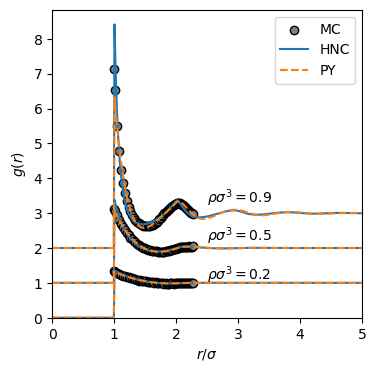

In [10]:
MCdata = np.loadtxt('data/radialdistribution_MCdata.dat',skiprows=1)
rMC, g20MC, g50MC, g90MC = MCdata[:,0],MCdata[:,1],MCdata[:,2],MCdata[:,3]

fig = plt.figure(figsize=(4,4))

plt.scatter(rMC,g20MC,marker='o',edgecolors='k',facecolors='grey',label='MC')
plt.scatter(rMC,g50MC+1,marker='o',edgecolors='k',facecolors='grey')
plt.scatter(rMC,g90MC+2,marker='o',edgecolors='k',facecolors='grey')

# Plot HNC results
plt.plot(r,gHNC[0],'-',color='C0',label='HNC')
plt.plot(r,gHNC[1]+1,'-',color='C0')
plt.plot(r,gHNC[2]+2,'-',color='C0')

# Plotting PY results
plt.plot(r,gPY[0],'--',color='C1',label='PY')
plt.plot(r,gPY[1]+1,'--',color='C1')
plt.plot(r,gPY[2]+2,'--',color='C1')

plt.xlim(0,5)
plt.ylim(0,None)
plt.legend(loc='best')
plt.xlabel('$r/\sigma$')
plt.ylabel('$g(r)$')
plt.text(2.5,3.3,r'$\rho \sigma^3 = 0.9$')
plt.text(2.5,2.2,r'$\rho \sigma^3 = 0.5$')
plt.text(2.5,1.1,r'$\rho \sigma^3 = 0.2$')
plt.savefig('radialdistributionfunction-hardspheres.png',dpi=200)


In [8]:
rhobarray = np.arange(0.01,1.1,0.1)
etaarray = (np.pi/6)*rhobarray

(1.0, 6.0)

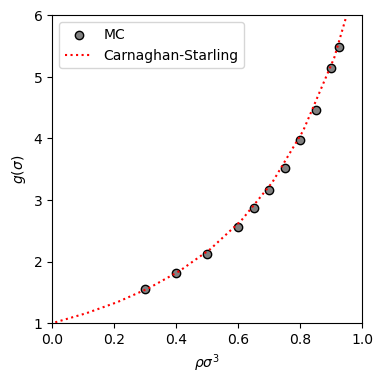

In [9]:
fig = plt.figure(figsize=(4,4))

# Contact Value
MCdata2 = np.loadtxt('data/radialdistribution_sigma_MCdata.dat',skiprows=1)
rhoMC, gsigmaMC = MCdata2[:,0],MCdata2[:,1]

gCS =  (1-0.5*etaarray)/(1-etaarray)**3

plt.scatter(rhoMC,gsigmaMC,marker='o',edgecolors='k',facecolors='grey',label='MC')
plt.plot(rhobarray,gCS,':',color='r',label='Carnaghan-Starling')
# plt.plot(rhobarray,gsigmaPY,'--k',label='PY')
# plt.plot(rhobarray,gsigmaHNC,'-k',label='HNC')
plt.legend(loc='best')
plt.xlabel(r'$\rho \sigma^3$')
plt.ylabel(r'$g(\sigma)$')
plt.xlim(0.0,1.0)
plt.ylim(1,6.0)
# plt.savefig('contactvalue-rdf-hardspheres.png',dpi=200)
# plt.show()
# plt.close()